In [58]:
import warnings

import decoupler as dc
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy import sparse
import pertpy as pt
import anndata as ad
import matplotlib.pyplot as plt
import gseapy as gp
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

warnings.filterwarnings("ignore")

In [2]:
adata_nk= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_nk

AnnData object with n_obs × n_vars = 207458 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age i

In [4]:
adata_nk.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_nk.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD56_dim CD16+ NK           171221
ILC1                         16331
CD56_dim CD16+ KLRC2+ NK     15081
iILC2                         2400
nILC2                         1554
CD56_bright CD16- NK           871
Name: count, dtype: int64

In [5]:
adata_nk.obs["pica_id"].unique()
adata_nk.obs["pica_id"].value_counts()

pica_id
PICA0133    6111
PICA0011    5146
PICA0086    3212
PICA0020    3203
PICA0015    2988
            ... 
PICA0001     540
PICA0040     520
PICA0003     475
PICA0142     430
PICA0119     383
Name: count, Length: 128, dtype: int64

In [6]:
adata_nk.obs['Batch'] = adata_nk.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata_nk.obs = adata_nk.obs.rename(columns={
    "Age (years)": "Age_years"
})

adata_nk.obs["Batch"] = adata_nk.obs["Batch"].astype("category")
adata_nk.obs["Age_years"] = adata_nk.obs["Age_years"].astype("float")
adata_nk.obs["Sex"] = adata_nk.obs["Sex"].astype("category")

In [7]:
adata_nk.obs["Sex"].value_counts()


Sex
Male      128680
Female     78778
Name: count, dtype: int64

In [8]:
adata_nk.obs["Age_years"].value_counts().sort_index()


Age_years
0.05     2551
0.07     1286
0.14      838
0.35      844
0.48      965
         ... 
16.16    1325
16.20    1371
16.29     641
16.78    1348
17.03    1763
Name: count, Length: 122, dtype: int64

### Prepare for DEG analysis (CD56_dim CD16+ NK)

In [9]:
nk_sub = adata_nk[
    adata_nk.obs["pica_cell_type_complete_01_gdT_corrected"] == "CD56_dim CD16+ NK"
].copy()

In [10]:
# make sure theres more than 1 donor
nk_sub.obs["pica_id"].value_counts()

pica_id
PICA0133    5519
PICA0011    4695
PICA0086    3035
PICA0020    3011
PICA0015    2818
            ... 
PICA0139     362
PICA0040     355
PICA0098     306
PICA0119     231
PICA0142     229
Name: count, Length: 128, dtype: int64

In [11]:
# make sure every donor has one value for variates
nk_sub.obs.groupby("pica_id")[["Age_years", "Sex", "Batch"]].nunique().head()

,Age_years,Sex,Batch
pica_id,,,
PICA0001,1,1,1
PICA0002,1,1,1
PICA0003,1,1,1
PICA0004,1,1,1
PICA0005,1,1,1


In [ ]:
# ensure that there are enough NK cells per donor
cell_counts_per_donor = nk_sub.obs["pica_id"].value_counts().sort_values()
print(cell_counts_per_donor)

pica_id
PICA0142     229
PICA0119     231
PICA0098     306
PICA0040     355
PICA0139     362
            ... 
PICA0015    2818
PICA0020    3011
PICA0086    3035
PICA0011    4695
PICA0133    5519
Name: count, Length: 128, dtype: int64


In [66]:
cell_counts_per_donor.describe()

count     128.000000
mean     1337.664062
std       781.344795
min       229.000000
25%       855.000000
50%      1191.000000
75%      1722.500000
max      5519.000000
Name: count, dtype: float64

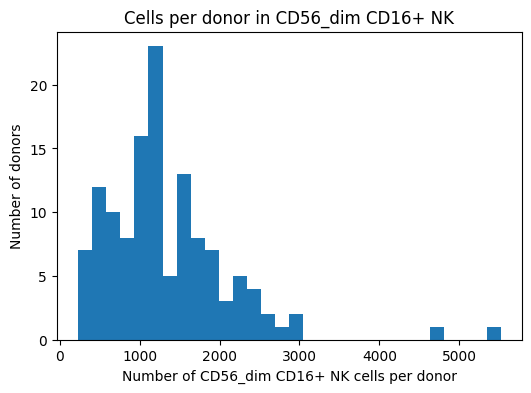

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(cell_counts_per_donor, bins=30)
plt.xlabel("Number of CD56_dim CD16+ NK cells per donor")
plt.ylabel("Number of donors")
plt.title("Cells per donor in CD56_dim CD16+ NK")
plt.show()

#### create pseudobulk counts (CD56_dim CD16+ NK)

In [12]:
# raw counts
X = nk_sub.layers["counts"]
if sparse.issparse(X):
    X = X.tocsr()

sample_ids_nkdim = nk_sub.obs["pica_id"].astype(str)
unique_samples_nkdim = sample_ids_nkdim.unique()

# sum counts for each donor
pb_counts_nkdim = []
for sid in unique_samples_nkdim:
    idx = np.where(sample_ids_nkdim == sid)[0]
    summed = np.asarray(X[idx].sum(axis=0)).ravel()
    pb_counts_nkdim.append(summed)

pb_counts_nkdim = np.vstack(pb_counts_nkdim)

# make pseudobulk AnnData
adata_pb_nkdim = ad.AnnData(
    X=pb_counts_nkdim,
    obs=pd.DataFrame(index=unique_samples_nkdim),
    var=nk_sub.var.copy()
)

# add donor metadata
donor_meta_nkdim = (
    nk_sub.obs[["pica_id", "Age_years", "Sex", "Batch"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)

adata_pb_nkdim.obs = donor_meta_nkdim.loc[adata_pb_nkdim.obs_names].copy()

adata_pb_nkdim

AnnData object with n_obs × n_vars = 128 × 38606
    obs: 'Age_years', 'Sex', 'Batch'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'

In [13]:
adata_pb_nkdim.obs_names[:10]

CategoricalIndex(['PICA0020', 'PICA0023', 'PICA0022', 'PICA0010', 'PICA0008',
                  'PICA0009', 'PICA0029', 'PICA0028', 'PICA0024', 'PICA0025'],
                 categories=['PICA0001', 'PICA0002', 'PICA0003', 'PICA0004', ..., 'PICA0166', 'PICA0168', 'PICA0169', 'PICA0173'], ordered=False, dtype='category')

### PCA (CD56_dim CD16+ NK)

In [14]:
adata_pb_pca_nkdim = adata_pb_nkdim.copy()

adata_pb_pca_nkdim.layers["counts"] = adata_pb_pca_nkdim.X.copy()

sc.pp.normalize_total(adata_pb_pca_nkdim, target_sum=1e4)
sc.pp.log1p(adata_pb_pca_nkdim)
sc.pp.scale(adata_pb_pca_nkdim, max_value=10)

sc.tl.pca(adata_pb_pca_nkdim)

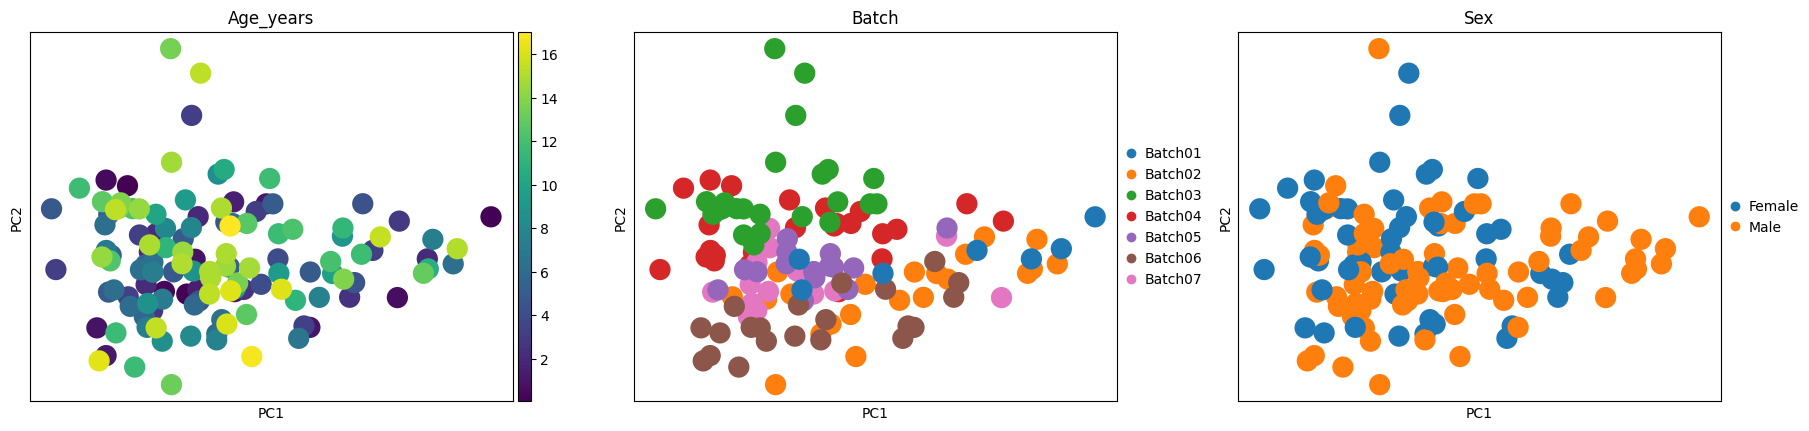

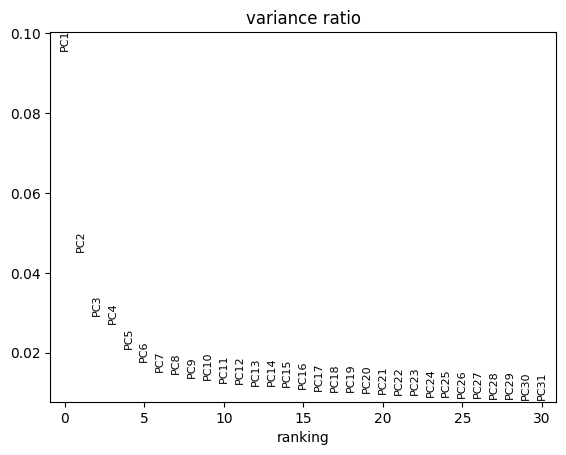

In [15]:
sc.pl.pca(adata_pb_pca_nkdim, color=["Age_years", "Batch", "Sex"])
sc.pl.pca_variance_ratio(adata_pb_pca_nkdim)

### run DESeq2 (CD56_dim CD16+ NK)

In [16]:
dds_nkdim = DeseqDataSet(
    adata=adata_pb_nkdim,
    design="~ Age_years + Sex + Batch",
    refit_cooks=True
)

dds_nkdim.deseq2()

Fitting size factors...
... done in 0.10 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.13 seconds.

Fitting dispersion trend curve...
... done in 0.50 seconds.

Fitting MAP dispersions...
... done in 7.32 seconds.

Fitting LFCs...
... done in 5.35 seconds.

Calculating cook's distance...
... done in 0.12 seconds.

Replacing 0 outlier genes.



In [17]:
print(type(dds_nkdim))
print(dir(dds_nkdim)[:50])

<class 'pydeseq2.dds.DeseqDataSet'>
['T', 'X', '_BACKED_ATTRS', '_H5_ALIASES', '_H5_ALIASES_NAMES', '_X', '__annotations__', '__class__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_adata_ref', '_check_dimensions', '_check_full_rank_design', '_check_uniqueness', '_clean_up_old_format', '_fit_MoM_dispersions', '_fit_iterate_size_factors', '_fit_mean_dispersion_trend', '_fit_parametric_dispersion_trend', '_gen_repr', '_get_X', '_get_and_delete_multicol_field']


In [18]:
print(dds_nkdim.obsm.keys())
print(dds_nkdim.obs.columns)

KeysView(AxisArrays with keys: design_matrix, _mu_LFC, _hat_diagonals)
Index(['Age_years', 'Sex', 'Batch', 'size_factors', 'replaceable'], dtype='object')


In [19]:
dds_nkdim.obsm["design_matrix"].head()

,Intercept,Age_years,Sex[T.Male],Batch[T.Batch02],Batch[T.Batch03],Batch[T.Batch04],Batch[T.Batch05],Batch[T.Batch06],Batch[T.Batch07]
PICA0020,1.0,15.52,1,1,0,0,0,0,0
PICA0023,1.0,4.80,1,1,0,0,0,0,0
PICA0022,1.0,12.72,1,1,0,0,0,0,0
PICA0010,1.0,0.07,0,1,0,0,0,0,0
PICA0008,1.0,9.70,0,1,0,0,0,0,0


In [20]:
design_cols_nkdim = list(dds_nkdim.obsm["design_matrix"].columns)
print(design_cols_nkdim)

contrast_nkdim = np.zeros(len(design_cols_nkdim))
contrast_nkdim[design_cols_nkdim.index("Age_years")] = 1

contrast_nkdim

['Intercept', 'Age_years', 'Sex[T.Male]', 'Batch[T.Batch02]', 'Batch[T.Batch03]', 'Batch[T.Batch04]', 'Batch[T.Batch05]', 'Batch[T.Batch06]', 'Batch[T.Batch07]']


array([0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [21]:
stat_res_nkdim = DeseqStats(
    dds_nkdim,
    contrast=contrast_nkdim
)

stat_res_nkdim.summary()

deg_results_nkdim = stat_res_nkdim.results_df
deg_results_nkdim.head()

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 1. 0. 0. 0. 0. 0. 0. 0.]
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
DDX11L2          0.138099       -0.012438  0.065924 -0.188675  0.850348   NaN
MIR1302-2HG      0.017574       -0.005450  0.307020 -0.017751  0.985838   NaN
FAM138A          0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000290826  0.000000             NaN       NaN       NaN       NaN   NaN
OR4F5            0.000000             NaN       NaN       NaN       NaN   NaN
...                   ...             ...       ...       ...       ...   ...
ENSG00000277836  0.014484        0.002488  0.307194  0.008100  0.993537   NaN
ENSG00000278633  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000276017  0.011239       -0.006994  0.307149 -0.022772  0.981832   NaN
ENSG00000278817  0.546614       -0.013876  0.040095 -0.346078  0.729284   NaN
ENSG00000277196  0.023400       -0.012404  0.306974 -0.040

... done in 2.36 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
DDX11L2,0.138099,-0.012438,0.065924,-0.188675,0.850348,NaN
MIR1302-2HG,0.017574,-0.005450,0.307020,-0.017751,0.985838,NaN
FAM138A,0.000000,NaN,NaN,NaN,NaN,NaN
ENSG00000290826,0.000000,NaN,NaN,NaN,NaN,NaN
OR4F5,0.000000,NaN,NaN,NaN,NaN,NaN


In [22]:
deg_results_nkdim.to_csv(
    "/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dimCD16_DEG_age_sex_batch.csv"
)

In [23]:
# top hits
deg_results_nkdim.sort_values("padj").head(20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
NR3C2,49.082711,0.128078,0.012169,10.524778,6.641764e-26,1.256755e-21
RADX,44.291545,0.120123,0.011823,10.160458,2.976737e-24,2.816290e-20
SELENOM,60.886212,0.123178,0.012223,10.077908,6.918308e-24,4.363608e-20
KIF21A,323.634848,0.138908,0.014410,9.639670,5.436251e-22,2.571619e-18
MEGF9,445.739274,0.041845,0.004459,9.384706,6.309242e-21,2.387670e-17
MID2,7.466805,0.180069,0.019364,9.299136,1.415920e-20,4.465339e-17
NAP1L2,20.734733,0.113919,0.013041,8.735447,2.426951e-18,6.560394e-15
DMTN,19.572119,0.110915,0.012746,8.701679,3.270085e-18,7.734569e-15
LARGE1,30.896057,0.136165,0.015807,8.614442,7.028292e-18,1.477659e-14
AGAP1,322.349871,0.094524,0.011176,8.457695,2.727142e-17,5.130883e-14


In [ ]:
# filter significant genes
sig_deg_nkdim = deg_results_nkdim.query("padj < 0.05").copy()
sig_deg_nkdim.sort_values("padj").head(20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
NR3C2,49.082711,0.128078,0.012169,10.524778,6.641764e-26,1.256755e-21
RADX,44.291545,0.120123,0.011823,10.160458,2.976737e-24,2.816290e-20
SELENOM,60.886212,0.123178,0.012223,10.077908,6.918308e-24,4.363608e-20
KIF21A,323.634848,0.138908,0.014410,9.639670,5.436251e-22,2.571619e-18
MEGF9,445.739274,0.041845,0.004459,9.384706,6.309242e-21,2.387670e-17
MID2,7.466805,0.180069,0.019364,9.299136,1.415920e-20,4.465339e-17
NAP1L2,20.734733,0.113919,0.013041,8.735447,2.426951e-18,6.560394e-15
DMTN,19.572119,0.110915,0.012746,8.701679,3.270085e-18,7.734569e-15
LARGE1,30.896057,0.136165,0.015807,8.614442,7.028292e-18,1.477659e-14
STX3,38.482411,0.079577,0.009421,8.447238,2.982756e-17,5.130883e-14


In [64]:

pds2.plot_volcano(sig_deg_nkdim, log2fc_thresh=0)


NameError: name 'pds2' is not defined

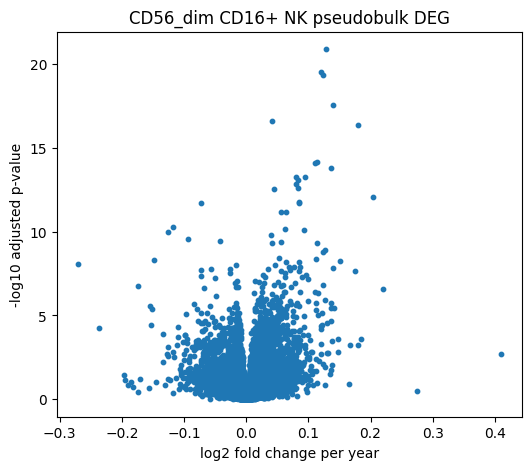

In [25]:
plot_df_nkdim = deg_results_nkdim.copy()
plot_df_nkdim = plot_df_nkdim.dropna(subset=["padj", "log2FoldChange"])
plot_df_nkdim["sig"] = plot_df_nkdim["padj"] < 0.05

plt.figure(figsize=(6,5))
plt.scatter(
    plot_df_nkdim["log2FoldChange"],
    -np.log10(plot_df_nkdim["padj"]),
    s=10
)
plt.xlabel("log2 fold change per year")
plt.ylabel("-log10 adjusted p-value")
plt.title("CD56_dim CD16+ NK pseudobulk DEG")
plt.show()

### Extract significant genes (CD56_dim CD16+ NK)

In [26]:
sig_deg_nkdim = deg_results_nkdim[
    (deg_results_nkdim["padj"] < 0.05) &
    (abs(deg_results_nkdim["log2FoldChange"]) > 0.1)
]

sig_deg_nkdim.sort_values("padj").head(20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
NR3C2,49.082711,0.128078,0.012169,10.524778,6.641764e-26,1.256755e-21
RADX,44.291545,0.120123,0.011823,10.160458,2.976737e-24,2.816290e-20
SELENOM,60.886212,0.123178,0.012223,10.077908,6.918308e-24,4.363608e-20
KIF21A,323.634848,0.138908,0.014410,9.639670,5.436251e-22,2.571619e-18
MID2,7.466805,0.180069,0.019364,9.299136,1.415920e-20,4.465339e-17
NAP1L2,20.734733,0.113919,0.013041,8.735447,2.426951e-18,6.560394e-15
DMTN,19.572119,0.110915,0.012746,8.701679,3.270085e-18,7.734569e-15
LARGE1,30.896057,0.136165,0.015807,8.614442,7.028292e-18,1.477659e-14
ENSG00000237471,7.714145,0.203219,0.025188,8.068239,7.131936e-16,8.434406e-13
LGALS3BP,16.483651,-0.118161,0.015743,-7.505511,6.118934e-14,5.262839e-11


In [27]:
sig_deg_nkdim.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dimCD16_age_DEG_significant.csv")

In [28]:
# seperate genes that increase vs decrease
up_genes_nkdim = sig_deg_nkdim[sig_deg_nkdim["log2FoldChange"] > 0]
down_genes_nkdim = sig_deg_nkdim[sig_deg_nkdim["log2FoldChange"] < 0]

print("Genes increasing with age:", len(up_genes_nkdim))
print("Genes decreasing with age:", len(down_genes_nkdim))

Genes increasing with age: 62
Genes decreasing with age: 26


In [29]:
up_genes_nkdim.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dimCD16_age_upregulated.csv")
down_genes_nkdim.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dimCD16_age_downregulated.csv")

### Visualize top genes (CD56_dim CD16+ NK)

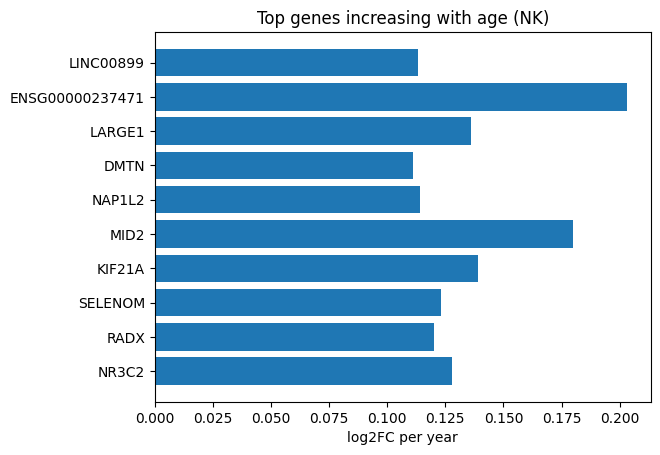

In [30]:
top_up_nkdim = up_genes_nkdim.sort_values("padj").head(10)

plt.figure()
plt.barh(top_up_nkdim.index, top_up_nkdim["log2FoldChange"])
plt.xlabel("log2FC per year")
plt.title("Top genes increasing with age (NK)")
plt.show()

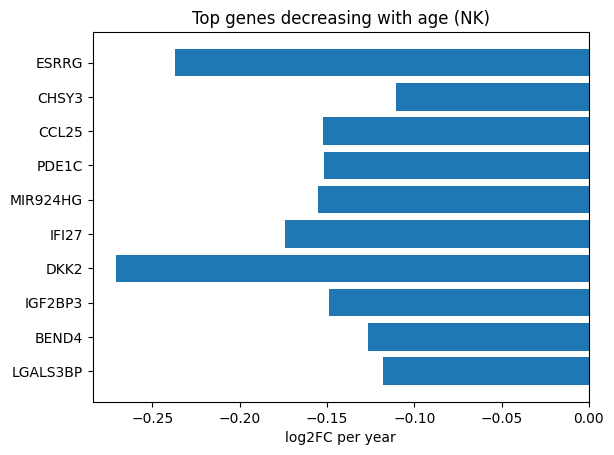

In [31]:
top_down_nkdim = down_genes_nkdim.sort_values("padj").head(10)

plt.figure()
plt.barh(top_down_nkdim.index, top_down_nkdim["log2FoldChange"])
plt.xlabel("log2FC per year")
plt.title("Top genes decreasing with age (NK)")
plt.show()

### Pathway enrichment (CD56_dim CD16+ NK)

In [33]:
# upregulated genes
gene_list_up_nkdim = up_genes_nkdim.index.tolist()

enr_nkdim_up = gp.enrichr(
    gene_list=gene_list_up_nkdim,
    organism="homo sapiens",
    gene_sets=[
    "GO_Biological_Process_2021",
    "KEGG_2021_Human",
    "MSigDB_Hallmark_2020"
]
)

enr_nkdim_up.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,neuron cell-cell adhesion (GO:0007158),2/16,0.001103,0.206984,0,0,47.438095,323.026850,NLGN4Y;NCAM2
1,GO_Biological_Process_2021,presynaptic endocytosis (GO:0140238),2/27,0.003157,0.206984,0,0,26.550667,152.880692,NLGN4Y;SYT1
2,GO_Biological_Process_2021,synaptic vesicle recycling (GO:0036465),2/34,0.004976,0.206984,0,0,20.735417,109.961316,NLGN4Y;SYT1
3,GO_Biological_Process_2021,synaptic vesicle endocytosis (GO:0048488),2/38,0.006187,0.206984,0,0,18.427778,93.712281,NLGN4Y;SYT1
4,GO_Biological_Process_2021,regulation of exocytosis (GO:0017157),2/52,0.011349,0.206984,0,0,13.258667,59.380090,SYT1;STXBP6


In [34]:
enr_nkdim.results.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dim_up_age_enrichment.csv", index=False)

In [35]:
# downregulated genes
gene_list_down_nkdim = down_genes_nkdim.index.tolist()

enr_nkdim_down = gp.enrichr(
    gene_list=gene_list_down_nkdim,
    organism="homo sapiens",
    gene_sets=[
    "GO_Biological_Process_2021",
    "KEGG_2021_Human",
    "MSigDB_Hallmark_2020"
]
)

enr_nkdim_down.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,monocyte chemotaxis (GO:0002548),2/42,0.001355,0.120683,0,0,41.529167,274.252651,CCL25;FLT1
1,GO_Biological_Process_2021,positive regulation of phospholipase C activit...,2/43,0.001420,0.120683,0,0,40.514228,265.652860,FLT1;GPR55
2,GO_Biological_Process_2021,cellular defense response (GO:0006968),2/49,0.001841,0.120683,0,0,35.331560,222.506241,LGALS3BP;NCR2
3,GO_Biological_Process_2021,positive regulation of cell-substrate adhesion...,2/70,0.003717,0.120683,0,0,24.394608,136.483580,CCL25;LIMS2
4,GO_Biological_Process_2021,phospholipase C-activating G protein-coupled r...,2/81,0.004943,0.120683,0,0,20.986287,111.431175,PTGER3;GPR55


In [36]:
enr_nkdim_down.results.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dim_down_age_enrichment.csv", index=False)

In [37]:
## all significant genes
gene_list_nkdim = sig_deg_nkdim.index.tolist()

enr_nkdim = gp.enrichr(
    gene_list=gene_list_nkdim,
    organism="homo sapiens",
    gene_sets=[
    "GO_Biological_Process_2021",
    "KEGG_2021_Human",
    "MSigDB_Hallmark_2020"
]
)

enr_nkdim.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,positive regulation of integrin-mediated signa...,2/7,0.000396,0.202074,0,0,92.590698,725.312331,DMTN;LIMS2
1,GO_Biological_Process_2021,regulation of integrin-mediated signaling path...,2/14,0.001683,0.324136,0,0,38.565891,246.329311,DMTN;LIMS2
2,GO_Biological_Process_2021,neuron cell-cell adhesion (GO:0007158),2/16,0.002207,0.324136,0,0,33.053156,202.163597,NLGN4Y;NCAM2
3,GO_Biological_Process_2021,positive regulation of cell-substrate adhesion...,3/70,0.003643,0.324136,0,0,10.453907,58.699404,CCL25;DMTN;LIMS2
4,GO_Biological_Process_2021,presynaptic endocytosis (GO:0140238),2/27,0.006255,0.324136,0,0,18.499535,93.874123,NLGN4Y;SYT1


In [38]:
enr_nkdim_down.results.to_csv("/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dim_age_enrichment.csv", index=False)

### Run GSEA 
for effect size rather than significant ones

In [39]:
ranked_genes_nkdim = deg_results_nkdim[["log2FoldChange"]].copy()

ranked_genes_nkdim = ranked_genes_nkdim.dropna()

ranked_genes_nkdim = ranked_genes_nkdim.sort_values(
    by="log2FoldChange",
    ascending=False
)

ranked_genes_nkdim.head()

,log2FoldChange
SYT1,0.409555
PNMA8A,0.274389
IGFBP3,0.219930
ENSG00000237471,0.203219
PRR16,0.185257


In [40]:
rnk_nkdim = ranked_genes_nkdim["log2FoldChange"]
rnk_nkdim.index = ranked_genes_nkdim.index

In [41]:
gsea_res_nkdim = gp.prerank(
    rnk=rnk_nkdim,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    outdir=None,
    seed=6
)

2026-03-09 01:24:29,915 [WARNING] Duplicated values found in preranked stats: 4.60% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [42]:
gsea_res_nkdim.res2d.head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,-0.60943,-2.422395,0.0,0.0,0.0,90/200,23.14%,KIF18B;AURKB;E2F8;DEPDC1;DLGAP5;KIF2C;MELK;BIR...
1,prerank,Interferon Alpha Response,-0.650215,-2.335694,0.0,0.0,0.0,54/97,18.83%,IFI27;IFI44L;LGALS3BP;OAS1;MX1;IFI44;CMPK2;USP...
2,prerank,G2-M Checkpoint,-0.586278,-2.307427,0.0,0.0,0.0,84/199,20.78%,AURKB;E2F2;KIF2C;PBK;BIRC5;UBE2C;KIF4A;CENPF;E...
3,prerank,Interferon Gamma Response,-0.48781,-1.955307,0.0,0.0,0.0,99/198,24.51%,IFI27;IFI44L;LGALS3BP;PTGS2;IFIT1;MX1;PLA2G4A;...
4,prerank,Mitotic Spindle,-0.443998,-1.743223,0.0,0.002289,0.007,60/199,23.56%,CDC42BPA;DLGAP5;KIF2C;BIRC5;ANLN;KIF4A;CENPF;E...
5,prerank,Notch Signaling,-0.535899,-1.560599,0.020316,0.028064,0.1,6/31,7.75%,DLL1;DTX1;FZD1;JAG1;NOTCH3;DTX4
6,prerank,UV Response Dn,-0.37788,-1.434824,0.006726,0.077536,0.286,30/141,14.81%,LAMC1;CDC42BPA;PLCB4;DDAH1;COL1A2;MMP16;COL1A1...
7,prerank,Wnt-beta Catenin Signaling,-0.440946,-1.36324,0.060345,0.125267,0.445,11/42,14.15%,GNAI1;DLL1;DKK4;AXIN2;LEF1;FZD1;JAG1;TCF7;NKD1...
8,prerank,TNF-alpha Signaling via NF-kB,-0.327054,-1.291452,0.023474,0.209436,0.663,66/199,19.84%,PTGS2;GPR183;CXCL3;VEGFA;SNN;NR4A3;DUSP4;CCRL2...
9,prerank,TGF-beta Signaling,-0.395824,-1.287628,0.103524,0.193888,0.67,10/54,11.04%,SMAD1;NOG;LEFTY2;SERPINE1;ID3;PMEPA1;SMAD6;BCA...


In [43]:
gsea_res_nkdim.res2d.to_csv(
    "/scratch/user/s4575250/BIOX7014_thesis/Results/PICA_Batch001-Batch007/03_DEG/NK_CD56dim_age_GSEA_results.csv"
)

[<Axes: xlabel='Gene Rank', ylabel='Ranked metric'>,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>]

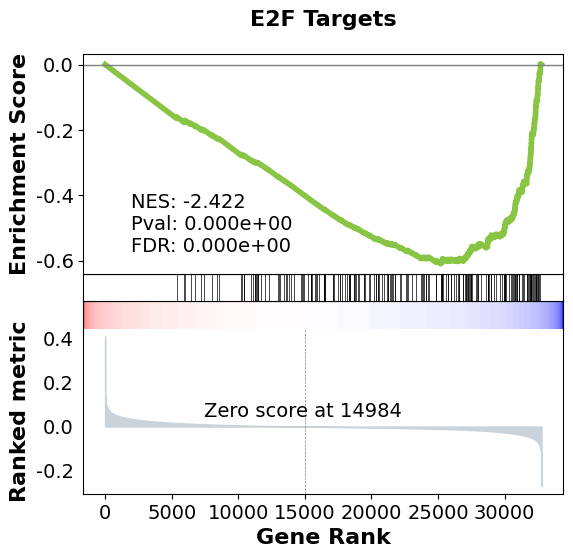

In [45]:
term = gsea_res_nkdim.res2d.iloc[0]["Term"]

gp.plot.gseaplot(
    rank_metric=rnk_nkdim,
    term=term,
    **gsea_res_nkdim.results[term]
)

### heatmap of top age-associated genes

In [48]:
up_nkdim = (
    deg_results_nkdim
    .query("padj < 0.05 and log2FoldChange > 0")
    .sort_values("padj")
    .head(15)
    .index
    .tolist()
)

down_nkdim = (
    deg_results_nkdim
    .query("padj < 0.05 and log2FoldChange < 0")
    .sort_values("padj")
    .head(15)
    .index
    .tolist()
)

top_genes_nkdim = up_nkdim + down_nkdim
len(top_genes_nkdim), top_genes_nkdim[:5]

(30, ['NR3C2', 'RADX', 'SELENOM', 'KIF21A', 'MEGF9'])

In [49]:
# normalize

adata_pb_nkdim_heat = adata_pb_nkdim.copy()

sc.pp.normalize_total(adata_pb_nkdim_heat, target_sum=1e4)
sc.pp.log1p(adata_pb_nkdim_heat)
sc.pp.scale(adata_pb_nkdim_heat, max_value=2)

# order donors by age
adata_pb_nkdim_heat = adata_pb_nkdim_heat[
    adata_pb_nkdim_heat.obs.sort_values("Age_years").index
].copy()

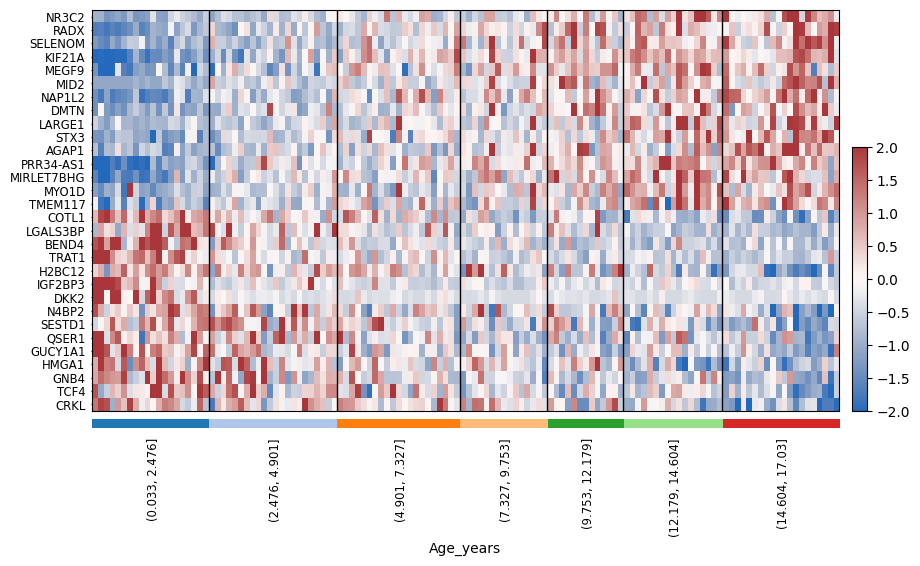

In [50]:
sc.pl.heatmap(
    adata_pb_nkdim_heat,
    var_names=top_genes_nkdim,
    groupby="Age_years",
    cmap="vlag",
    swap_axes=True
)

In [51]:
# add age_group for psuedobulk plot

adata_pb_nkdim_heat.obs["Age_group"] = pd.cut(
    adata_pb_nkdim_heat.obs["Age_years"],
    bins=[0, 3, 6, 10, 14, 18],
    labels=["0-3", "4-6", "7-10", "11-14", "15-18"],
    include_lowest=True
)

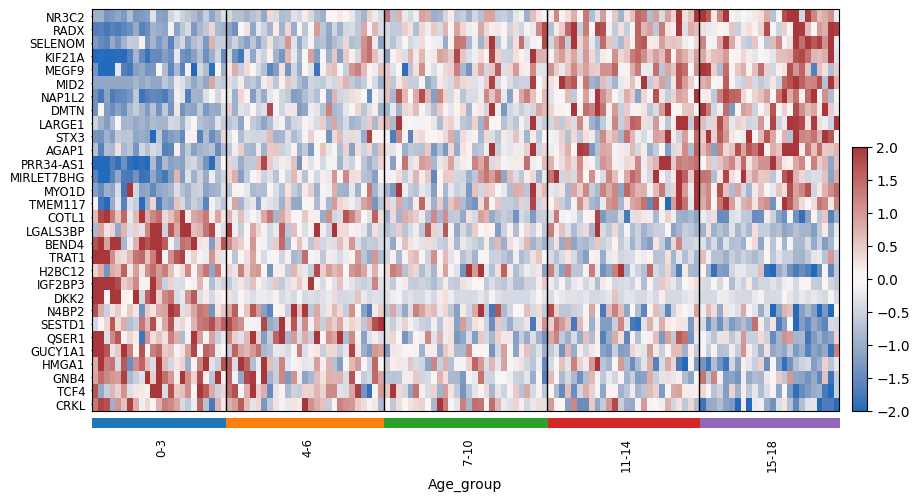

In [52]:
sc.pl.heatmap(
    adata_pb_nkdim_heat,
    var_names=top_genes_nkdim,
    groupby="Age_group",
    cmap="vlag",
    swap_axes=True
)

### Aging signature score across single NK cells
Age score = (genes ↑ with age) − (genes ↓ with age)
High score → "older-like transcriptional state"
Low score → "younger-like transcriptional state"

In [53]:
age_up_genes = (
    deg_results_nkdim
    .query("padj < 0.05 and log2FoldChange > 0")
    .sort_values("padj")
    .head(30)
    .index
    .tolist()
)

age_down_genes = (
    deg_results_nkdim
    .query("padj < 0.05 and log2FoldChange < 0")
    .sort_values("padj")
    .head(30)
    .index
    .tolist()
)

In [54]:
sc.tl.score_genes(
    nk_sub,
    gene_list=age_up_genes,
    score_name="age_up_score"
)

sc.tl.score_genes(
    nk_sub,
    gene_list=age_down_genes,
    score_name="age_down_score"
)

nk_sub.obs["age_signature_score"] = (
    nk_sub.obs["age_up_score"] - nk_sub.obs["age_down_score"]
)

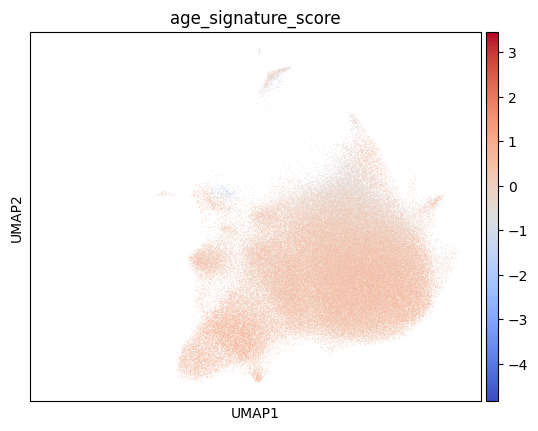

In [55]:
sc.pl.umap(
    nk_sub,
    color=["age_signature_score"],
    cmap="coolwarm"
)

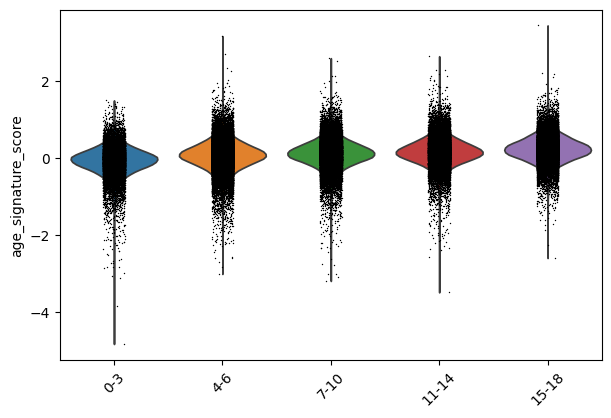

In [56]:
# plot signature by age group
nk_sub.obs["Age_group"] = pd.cut(
    nk_sub.obs["Age_years"],
    bins=[0, 3, 6, 10, 14, 18],
    labels=["0-3", "4-6", "7-10", "11-14", "15-18"],
    include_lowest=True
)

sc.pl.violin(
    nk_sub,
    keys="age_signature_score",
    groupby="Age_group",
    stripplot=True,
    rotation=45
)

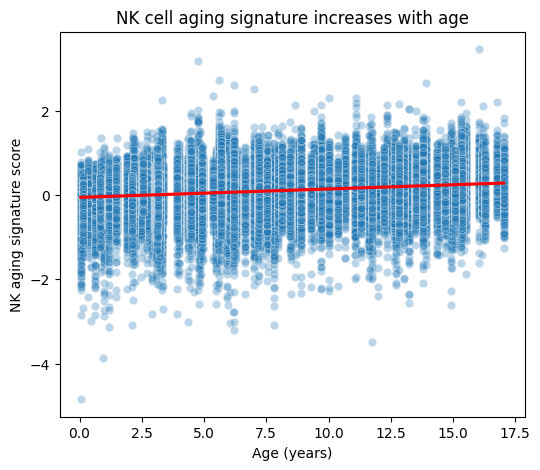

In [59]:
# NK aging trajectory plot (Age vs signature score)
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=nk_sub.obs,
    x="Age_years",
    y="age_signature_score",
    alpha=0.3
)

sns.regplot(
    data=nk_sub.obs,
    x="Age_years",
    y="age_signature_score",
    scatter=False,
    color="red"
)

plt.xlabel("Age (years)")
plt.ylabel("NK aging signature score")
plt.title("NK cell aging signature increases with age")

plt.show()

In [60]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    nk_sub.obs["Age_years"],
    nk_sub.obs["age_signature_score"]
)

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.2780185366762635
p-value: 0.0


There is a moderate positive correlation between NK aging signature and age.
NK cells from older donors tend to show stronger aging transcriptional programs.
But this plot is noisy because you have thousands of cells per donor.

Cells from the same donor are not independent observations.

In [62]:
donor_scores = (
    nk_sub.obs
    .groupby("pica_id")[["Age_years","age_signature_score"]]
    .mean()
    .reset_index()
)

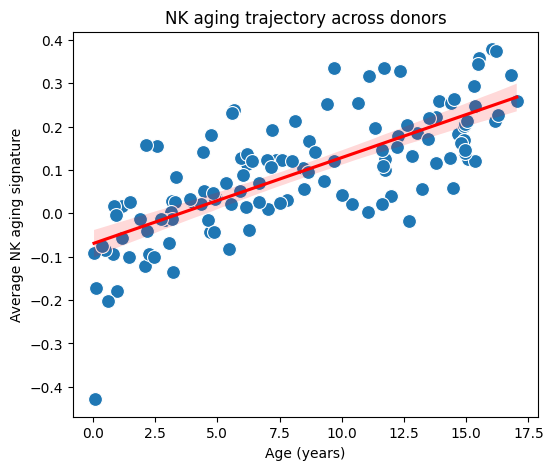

In [63]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=donor_scores,
    x="Age_years",
    y="age_signature_score",
    s=100
)

sns.regplot(
    data=donor_scores,
    x="Age_years",
    y="age_signature_score",
    scatter=False,
    color="red"
)

plt.xlabel("Age (years)")
plt.ylabel("Average NK aging signature")
plt.title("NK aging trajectory across donors")

plt.show()